In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Step 1: Load the dataset
df = pd.read_csv("C:\\Users\\landg\\Downloads\\Retail_Sales_Data.csv")

In [3]:
# Step 2: Explore the dataset
print(df.head())
print(df.info())

  Transaction_Date Region Product_Category  Quantity_Sold  Sales_Amount
0       2023-01-01   East        Groceries              7           758
1       2023-01-02   West         Clothing             17           915
2       2023-01-03  North         Clothing              4           307
3       2023-01-04   East        Furniture              5           230
4       2023-01-05   East         Clothing              7           503
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction_Date  100 non-null    object
 1   Region            100 non-null    object
 2   Product_Category  100 non-null    object
 3   Quantity_Sold     100 non-null    int64 
 4   Sales_Amount      100 non-null    int64 
dtypes: int64(2), object(3)
memory usage: 4.0+ KB
None


In [4]:
# Step 3: Aggregate total sales by region
sales_by_region = df.groupby("Region")["Sales_Amount"].sum().reset_index()

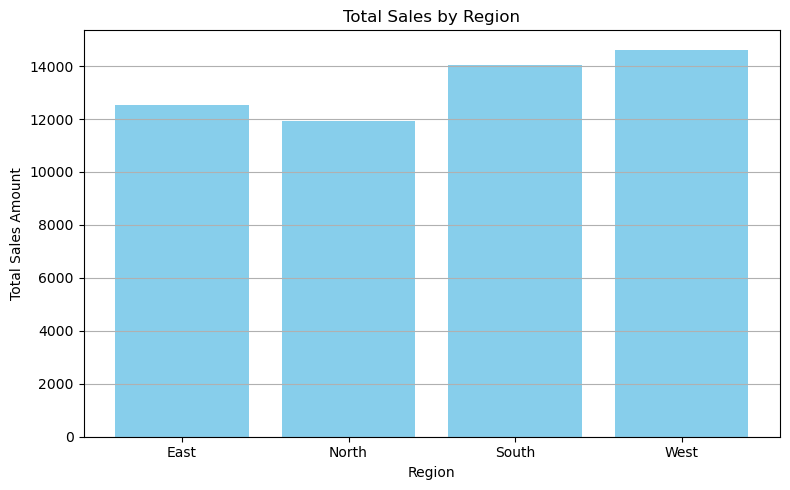

In [5]:
# Step 4: Bar plot of sales by region
plt.figure(figsize=(8, 5))
plt.bar(sales_by_region["Region"], sales_by_region["Sales_Amount"], color='skyblue')
plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales Amount")
plt.grid(axis='y')
plt.tight_layout()
plt.show()

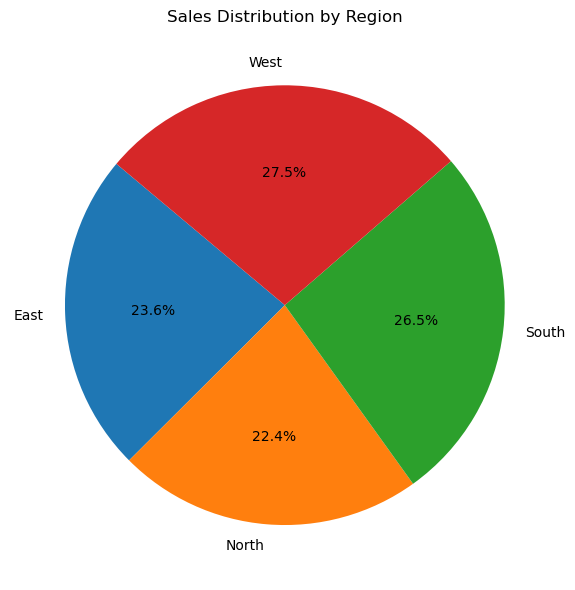

In [6]:
# Step 5: Pie chart of sales distribution by region
plt.figure(figsize=(6, 6))
plt.pie(sales_by_region["Sales_Amount"], labels=sales_by_region["Region"], autopct='%1.1f%%', startangle=140)
plt.title("Sales Distribution by Region")
plt.tight_layout()
plt.show()

In [7]:
# Step 6: Identify top-performing region
top_region = sales_by_region.sort_values(by="Sales_Amount", ascending=False).iloc[0]
print(f"Top Performing Region: {top_region['Region']} with Sales = {top_region['Sales_Amount']}")

Top Performing Region: West with Sales = 14618


In [8]:
# Step 7: Group by Region and Product Category
region_category_sales = df.groupby(["Region", "Product_Category"])["Sales_Amount"].sum().unstack().fillna(0)

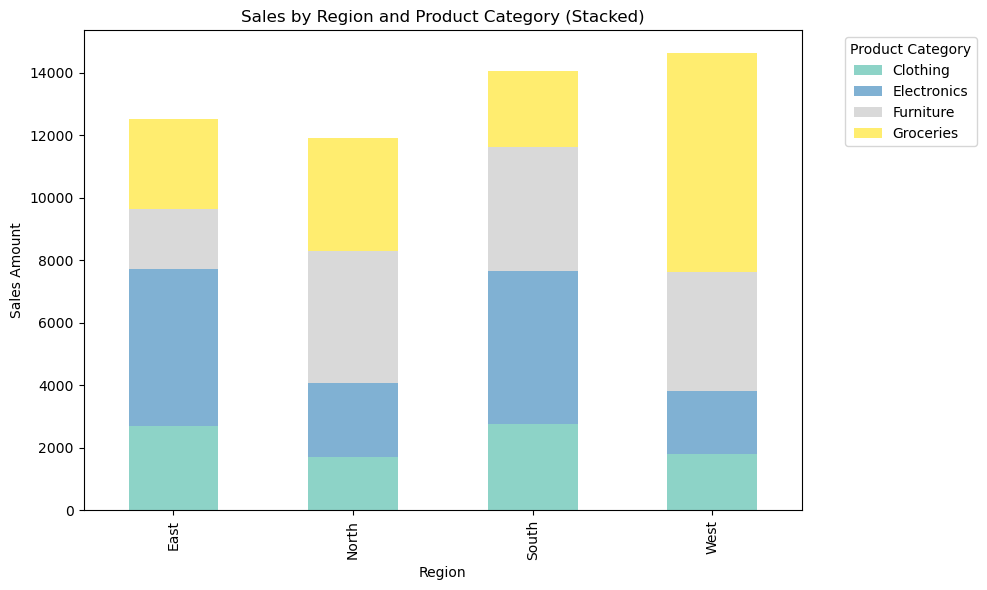

In [9]:
# Step 8: Stacked bar plot
region_category_sales.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set3')
plt.title("Sales by Region and Product Category (Stacked)")
plt.xlabel("Region")
plt.ylabel("Sales Amount")
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

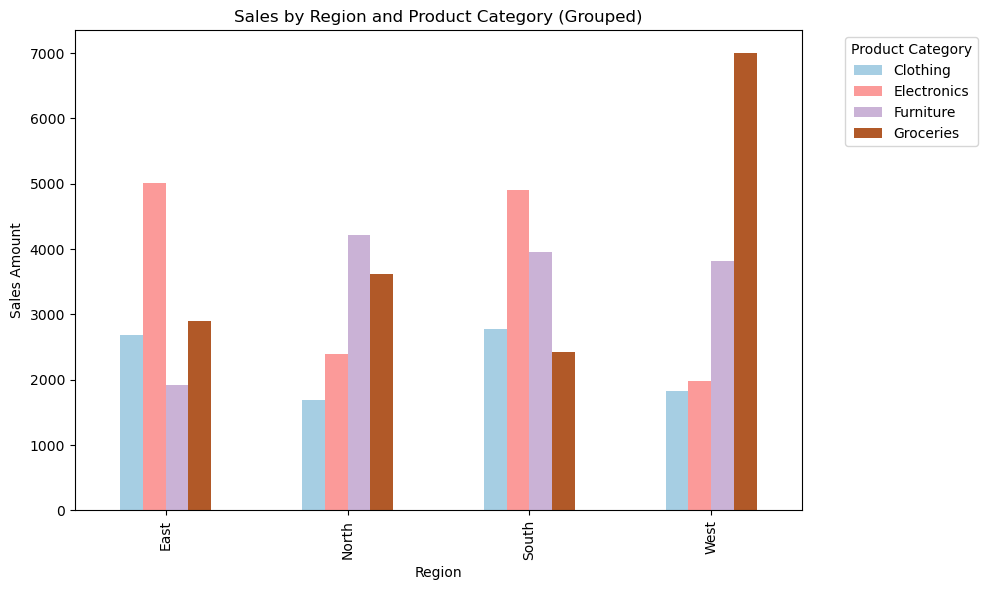

In [10]:
# Optional: Grouped bar plot
region_category_sales.plot(kind='bar', figsize=(10, 6), colormap='Paired')
plt.title("Sales by Region and Product Category (Grouped)")
plt.xlabel("Region")
plt.ylabel("Sales Amount")
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()